# Uncertainty under insufficient information

This notebook demonstrates two cases where Bayesian ARX predictive uncertainty should widen:

1. **Undersampling / Nyquist violation proxy** (aliased training data)
2. **Too few noisy samples** (weak identifiability)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from bayes_sysid import BayesianARX


In [6]:
def simulate_true_system(u, a=0.6, b=0.7, noise_std=0.1, seed=0):
    rng = np.random.default_rng(seed)
    y = np.zeros_like(u, dtype=float)
    for k in range(1, len(u)):
        y[k] = a * y[k-1] + b * u[k-1] + rng.normal(0.0, noise_std)
    return y

def posterior_rollout_band(model, y_init, u_future, n_samples=500, q=(0.05, 0.95), seed=0):
    paths = model.rollout_posterior_samples(
        y_init=y_init,
        u_future=u_future,
        n_parameter_samples=n_samples,
        include_process_noise=True,
        random_state=seed,
    )
    lo, hi = np.quantile(paths, [q[0], q[1]], axis=0)
    med = np.median(paths, axis=0)
    return med, lo, hi


## Case 1: Undersampling / Nyquist violation proxy

We generate a high-rate sequence with a fast oscillatory input and then downsample it aggressively for training.
The downsampled data acts as a proxy for violating sampling assumptions, and should yield wider predictive intervals.

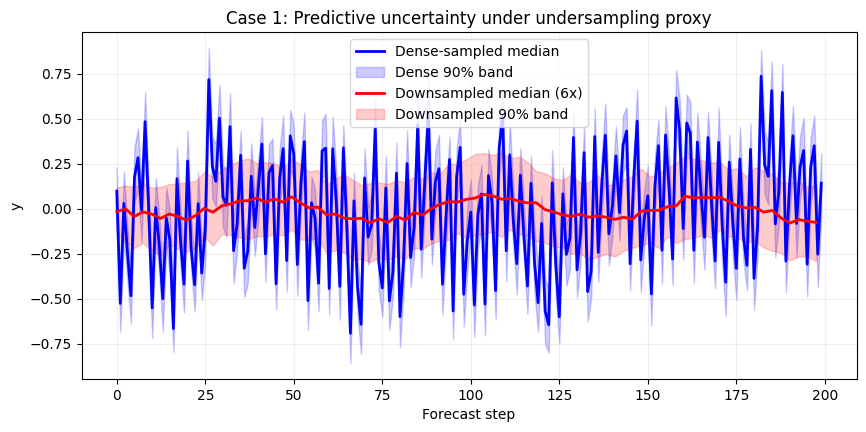

Avg 90% interval width (dense):      0.3275133415681236
Avg 90% interval width (downsampled): 0.39964713577041794


In [64]:
rng = np.random.default_rng(7)
n_hi = 1200
t_hi = np.arange(n_hi)
u_hi = np.sin(2 * np.pi * 0.34 * t_hi) + 0.25 * rng.normal(size=n_hi)
y_hi = simulate_true_system(u_hi, a=0.65, b=0.55, noise_std=0.08, seed=11)

# aggressive downsampling (aliasing/undersampling proxy)
ds = 6
u_lo = u_hi[::ds]
y_lo = y_hi[::ds]

n_train = 120
model_dense = BayesianARX(na=2, nb=2, sigma2=0.08**2).fit(y_hi[:n_train*ds], u_hi[:n_train*ds])
model_sparse = BayesianARX(na=2, nb=2, sigma2=0.08**2).fit(y_lo[:n_train], u_lo[:n_train])

h = 200
u_future_dense = u_hi[n_train*ds-2 : n_train*ds-2 + h + 1]
u_future_sparse = u_lo[n_train-2 : n_train-2 + h + 1]
y_init_dense = y_hi[0 : 2]

med_d, lo_d, hi_d = posterior_rollout_band(model_dense, y_init_dense, u_future_dense, seed=1, n_samples=h)
med_s, lo_s, hi_s = posterior_rollout_band(model_sparse, y_init_dense, u_future_sparse, seed=1, n_samples=h)

x = np.arange(h)
plt.figure(figsize=(10, 4.5))
# plt.scatter(t_hi[ :  h + 1], y_hi[ : h + 1], color='k', s=10, label='True system')
plt.plot(x, med_d, label='Dense-sampled median', lw=2, color='blue')
plt.fill_between(x, lo_d, hi_d, alpha=0.2, label='Dense 90% band', color="blue")
plt.plot(x[:len(med_s)]*h/len(med_s), med_s, label=f'Downsampled median ({ds}x)', lw=2, color='red')
plt.fill_between(x[:len(med_s)]*h/len(med_s), lo_s, hi_s, alpha=0.2, label='Downsampled 90% band', color='red')
# plt.scatter(x, y_lo[n_train*ds-2 : n_train*ds-2 + h + 1], color='k', s=20, label='True future')
plt.title('Case 1: Predictive uncertainty under undersampling proxy')
plt.xlabel('Forecast step')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print('Avg 90% interval width (dense):     ', float(np.mean(hi_d - lo_d)))
print('Avg 90% interval width (downsampled):', float(np.mean(hi_s - lo_s)))


## Case 2: Too few noisy samples

Hold the data-generating process fixed, but fit one model with many samples and one with very few samples.
The few-sample model should exhibit larger posterior predictive intervals.

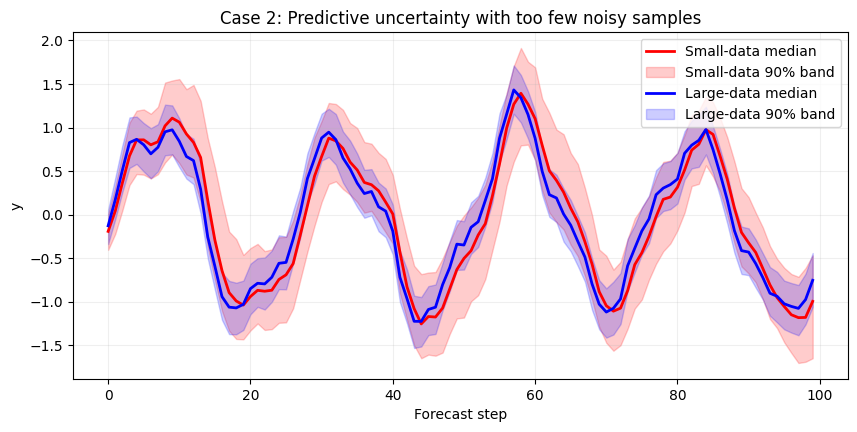

Avg 90% interval width (small-data): 0.9504132086966622
Avg 90% interval width (large-data): 0.5639749580507892


In [76]:
n = 900
t = np.arange(n)
u = 0.8*np.sin(2*np.pi*0.04*t) + 0.3*np.sin(2*np.pi*0.11*t) + 0.2*np.random.default_rng(5).normal(size=n)
y = simulate_true_system(u, a=0.7, b=0.45, noise_std=0.12, seed=22)

n_small, n_large = 10, 800
m_small = BayesianARX(na=2, nb=2, sigma2=0.12**2).fit(y[:n_small], u[:n_small])
m_large = BayesianARX(na=2, nb=2, sigma2=0.12**2).fit(y[:n_large], u[:n_large])

h = 100
u_future = u[: h + 1]
y_init = y[0 : 3]


med_sm, lo_sm, hi_sm = posterior_rollout_band(m_small, y_init, u_future, seed=3)
med_lg, lo_lg, hi_lg = posterior_rollout_band(m_large, y_init, u_future, seed=3)

x = np.arange(h)
plt.figure(figsize=(10, 4.5))
plt.plot(x, med_sm, label='Small-data median', lw=2, color='red')
plt.fill_between(x, lo_sm, hi_sm, alpha=0.2, label='Small-data 90% band', color='red')
plt.plot(x, med_lg, label='Large-data median', lw=2, color='blue')
plt.fill_between(x, lo_lg, hi_lg, alpha=0.2, label='Large-data 90% band', color='blue')
plt.title('Case 2: Predictive uncertainty with too few noisy samples')
plt.xlabel('Forecast step')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print('Avg 90% interval width (small-data):', float(np.mean(hi_sm - lo_sm)))
print('Avg 90% interval width (large-data):', float(np.mean(hi_lg - lo_lg)))


## Notes

- This is a qualitative demo, not a formal aliasing-identification proof.
- For stronger Nyquist experiments, use a known continuous-time plant and compare multiple sample periods.
- You can switch to `BayesianARXUnknownNoise` to include explicit uncertainty over noise variance.